<a href="https://colab.research.google.com/github/KSushrutha/Predicting-Enzyme-Activity/blob/main/EnzymePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Linear Regression Analysis for T=37°C, pH=7.0 ---
--- Using all 3 points for full kinetic analysis ---

--- Model Performance Metrics ---
Coefficient of Determination (R^2 Score): 0.9999 (This is your confidence score)
Mean Squared Error (MSE): 0.000000000
Model Slope (K_m/V_max): 0.0017968
Model Intercept (1/V_max): 0.0003231

--- Enzyme Kinetic Parameters (Derived from Model) ---
Vmax (Max Rate): 3095.21 uM/min
Km (Michaelis Constant): 5.562 mM


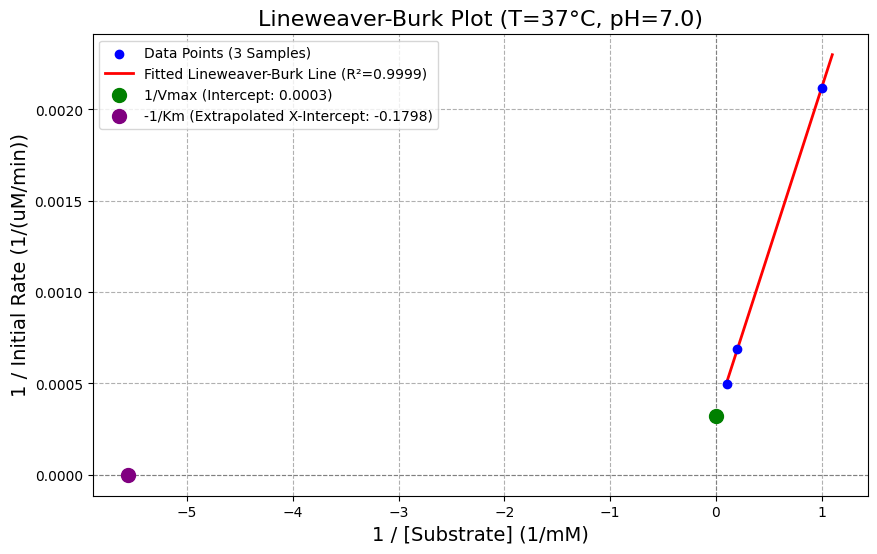


--- Actual vs. Predicted (Full Dataset) ---
| Reciprocal_Substrate   | Actual_Reciprocal_Rate   | Predicted_Reciprocal_Rate   |
|:-----------------------|:-------------------------|:----------------------------|
| 1                      | 0.00211909               | 0.00211993                  |
| 0.2                    | 0.000689941              | 0.000682449                 |
| 0.1                    | 0.000496106              | 0.000502765                 |


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the transformed dataset ---
try:
    df = pd.read_csv('/content/Data.csv')
except FileNotFoundError:
    print("Error: 'catalase_kinetics_lineweaver_burk.csv' not found.")
    print("Please ensure the transformed file is available.")
    exit()

# --- 2. Filter data for a single condition for accurate kinetic analysis ---
# The Lineweaver-Burk plot assumes constant temperature and pH.
# We will demonstrate the analysis for the optimal condition (37C, pH 7.0)
TEMP_C = 37
PH = 7.0
filtered_df = df[(df['Temperature_C'] == TEMP_C) & (df['pH'] == PH)].copy()

if filtered_df.empty:
    print(f"Error: No data found for Temperature={TEMP_C}C and pH={PH}. Exiting.")
    exit()

# Define X (Reciprocal Substrate) and Y (Reciprocal Rate)
# X must be reshaped for scikit-learn
X_all = filtered_df['Reciprocal_Substrate'].values.reshape(-1, 1)
Y_all = filtered_df['Reciprocal_Rate'].values

print(f"--- Linear Regression Analysis for T={TEMP_C}°C, pH={PH} ---")
print(f"--- Using all {len(Y_all)} points for full kinetic analysis ---")

# --- 3. TRAIN on ALL data (since we only have 3 points) ---
# We bypass train_test_split to get a valid R^2 for the overall model fit.
model = LinearRegression()
model.fit(X_all, Y_all) # Fit the model on all data points

# --- 4. Predict values using the full dataset (Y_pred_all) ---
Y_pred_all = model.predict(X_all)

# --- 5. Calculate Model Analytics (Confidence Scores) ---
# R^2 is calculated using ALL data (X_all, Y_all) vs. predictions (Y_pred_all)
score_r2 = r2_score(Y_all, Y_pred_all)
mse = mean_squared_error(Y_all, Y_pred_all)
slope = model.coef_[0]
intercept = model.intercept_

print("\n--- Model Performance Metrics ---")
print(f"Coefficient of Determination (R^2 Score): {score_r2:.4f} (This is your confidence score)")
print(f"Mean Squared Error (MSE): {mse:.9f}") # Increased precision for small error
print(f"Model Slope (K_m/V_max): {slope:.7f}")
print(f"Model Intercept (1/V_max): {intercept:.7f}")

# --- 6. Calculate Kinetic Parameters (Km and Vmax) ---
Vmax = 1 / intercept
Km = slope * Vmax

print("\n--- Enzyme Kinetic Parameters (Derived from Model) ---")
print(f"Vmax (Max Rate): {Vmax:.2f} uM/min")
print(f"Km (Michaelis Constant): {Km:.3f} mM")


# --- 7. Plot the Regression Line and Data ---
plt.figure(figsize=(10, 6))

# Plot all data points
plt.scatter(X_all, Y_all, color='blue', label=f'Data Points ({len(Y_all)} Samples)', zorder=3)

# Plot the full regression line
X_line = np.linspace(X_all.min(), X_all.max() * 1.1, 100).reshape(-1, 1)
Y_line = model.predict(X_line)
plt.plot(X_line, Y_line, color='red', linewidth=2, label=f'Fitted Lineweaver-Burk Line (R²={score_r2:.4f})')

# Mark the Intercepts
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.scatter([0], [intercept], color='green', marker='o', s=100, label=f'1/Vmax (Intercept: {intercept:.4f})', zorder=4)
plt.scatter([-Km], [0], color='purple', marker='o', s=100, label=f'-1/Km (Extrapolated X-Intercept: {-1/Km:.4f})', zorder=4)

plt.title(f'Lineweaver-Burk Plot (T={TEMP_C}°C, pH={PH})', fontsize=16)
plt.xlabel('1 / [Substrate] (1/mM)', fontsize=14)
plt.ylabel('1 / Initial Rate (1/(uM/min))', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# Print the predicted vs actual for the *full* dataset
print("\n--- Actual vs. Predicted (Full Dataset) ---")
results = pd.DataFrame({
    'Reciprocal_Substrate': X_all.flatten(),
    'Actual_Reciprocal_Rate': Y_all,
    'Predicted_Reciprocal_Rate': Y_pred_all
})
print(results.to_markdown(index=False, numalign="left", stralign="left"))